In [103]:
%load_ext autoreload
%autoreload 2


In [104]:
import fiftyone as fo
import fiftyone.zoo as foz

dataset = foz.load_zoo_dataset(
    "kinetics-700-2020",
    split="validation",
    classes=["grooming cat", "grooming dog"],
    max_samples=10,
)

session = fo.launch_app(dataset)

ModuleNotFoundError: No module named 'fiftyone'

In [112]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



Files already downloaded and verified
Files already downloaded and verified
Feature batch shape: torch.Size([64, 3, 32, 32])
Labels batch shape: torch.Size([64])


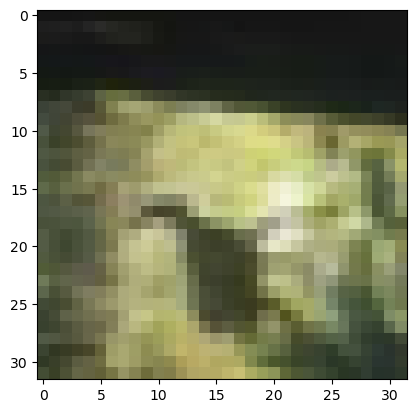

Label: 4


In [123]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt


training_data = datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)
test_data = datasets.CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)


from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img.transpose(0,2))
plt.show()
print(f"Label: {label}")

In [126]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvNet(nn.Module):

    def __init__(self):
        
        super().__init__()
        
        self.conv2d1 = nn.Conv2d(in_channels=3, out_channels=12, kernel_size=3)
        self.maxpool = nn.MaxPool2d(2)
        self.activation = nn.ReLU()
        self.conv2d2 = nn.Conv2d(in_channels=12, out_channels=6, kernel_size=3)
        self.conv2d3 = nn.Conv2d(in_channels=6, out_channels=2, kernel_size=3)
        self.fc1 = nn.Linear(216, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, img):
        
        # print("img shape: ", img.shape)
        x = self.conv2d1(img)
        x = self.activation(x)
        x = self.maxpool(x)
        
        # print("x shape: ", x.shape)
        
        x = self.conv2d2(x)
        x = self.activation(x)
        x = self.maxpool(x)
        
        # print("x shape: ", x.shape)
        
        # x = self.conv2d3(x)
        # x = self.activation(x)
        # x = self.maxpool(x)
        
        # print("x shape: ", x.shape)
        
        x = x.view(x.shape[0], -1)
        
        logits = self.fc2(self.activation(self.fc1(x)))
        # prob = F.softmax(logits, dim=0)
        
        return logits
        
        # conv
        
        # activation
        
    

In [127]:
model = ConvNet()
model = model.to(device=device)

out = model(img.unsqueeze(0))
print("out: ", out)
print("out shape", out.shape)


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cpu and cuda:0! (when checking argument for argument weight in method wrapper_CUDA___slow_conv2d_forward)

In [128]:
criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(100):
    for imgs, labels in train_dataloader:
        # print(imgs.shape)
        imgs = imgs.to(device=device)
        pred = model(imgs)
        # print("pred shape", pred.shape)
        labels_enc = F.one_hot(labels, num_classes=10).to(dtype=torch.float)
        labels_enc = labels_enc.to(device=device)
        loss = criterion(pred, labels_enc)
        
        print("loss", loss.item())
        
        optimizer.zero_grad()
        loss.backward()
        
        optimizer.step()
    
    
    
    

loss 2.2986931800842285
loss 2.2984495162963867
loss 2.308711051940918
loss 2.302581548690796
loss 2.2918105125427246
loss 2.303743839263916
loss 2.2876503467559814
loss 2.296314239501953
loss 2.306687355041504
loss 2.3036696910858154
loss 2.3065946102142334
loss 2.3022665977478027
loss 2.2882134914398193
loss 2.2958035469055176
loss 2.2934417724609375
loss 2.298801898956299
loss 2.2895233631134033
loss 2.276899814605713
loss 2.292454719543457
loss 2.2893478870391846
loss 2.298434257507324
loss 2.287374973297119
loss 2.2938601970672607
loss 2.287247657775879
loss 2.278013229370117
loss 2.2663164138793945
loss 2.2726287841796875
loss 2.271336555480957
loss 2.282564163208008
loss 2.264206886291504


loss 2.258038282394409
loss 2.272228479385376
loss 2.2232892513275146
loss 2.213334083557129
loss 2.1751112937927246
loss 2.291010856628418
loss 2.1783647537231445
loss 2.2187108993530273
loss 2.217348098754883
loss 2.2175631523132324
loss 2.1962575912475586
loss 2.199580192565918
loss 2.1710095405578613
loss 2.1406049728393555
loss 2.1275126934051514
loss 2.1799473762512207
loss 2.2088470458984375
loss 2.12099552154541
loss 2.140860080718994
loss 2.0967187881469727
loss 2.0994272232055664
loss 2.124049663543701
loss 2.0858914852142334
loss 2.0436010360717773
loss 2.06449556350708
loss 2.0279879570007324
loss 1.9638748168945312
loss 1.9722611904144287
loss 1.9180519580841064
loss 2.0105104446411133
loss 2.006427049636841
loss 1.9073121547698975
loss 2.021179437637329
loss 2.1390750408172607
loss 1.8919011354446411
loss 1.9705333709716797
loss 2.008136749267578
loss 1.789283275604248
loss 1.9002819061279297
loss 2.006584644317627
loss 1.9539768695831299
loss 1.8728225231170654
loss 1.82